In [145]:
# imports

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [146]:
# load data

df = pd.read_csv('resume_data.csv')

# remove bom character and whitespace from column names
df.columns = df.columns.str.strip().str.replace('﻿', '', regex=False)

# drop duplicate column
df = df.drop(columns=['responsibilities.1'])

# strip leading/trailing whitespace from all string values
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# normalize all string values to lowercase
df = df.map(lambda x: x.lower() if isinstance(x, str) else x)

# replace empty strings and n/a with None
df = df.replace({'': None, 'n/a': None})

In [147]:
# select features and target

# columns to use as features
feature_cols = ['skills', 'job_position_name', 'educationaL_requirements', 'responsibilities']

# drop rows where any feature or target is missing
df_model = df[feature_cols + ['matched_score']].dropna()

# combine all text features into a single string per row
df_model['combined'] = df_model[feature_cols].apply(lambda row: ' '.join(row.values), axis=1)

print(f"rows after dropping missing: {df_model.shape[0]}")

rows after dropping missing: 9488


In [148]:
# convert text to tfidf features

# initialize tfidf vectorizer
vectorizer = TfidfVectorizer(max_features=500)

# fit and transform the combined text column
X = vectorizer.fit_transform(df_model['combined'])

# target variable
y = df_model['matched_score'].values

In [149]:
# train/test split

# split into 80 train and 20 test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"training samples: {X_train.shape[0]}")
print(f"test samples: {X_test.shape[0]}")

training samples: 7590
test samples: 1898


In [150]:
# train linear regression model

# initialize and fit the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [151]:
# evaluate model

# predict on test set
y_pred = model.predict(X_test)

# compute mean squared error
mse = mean_squared_error(y_test, y_pred)

# compute r squared score
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"R2: {r2:.4f}")

MSE: 0.0147
R2: 0.4770


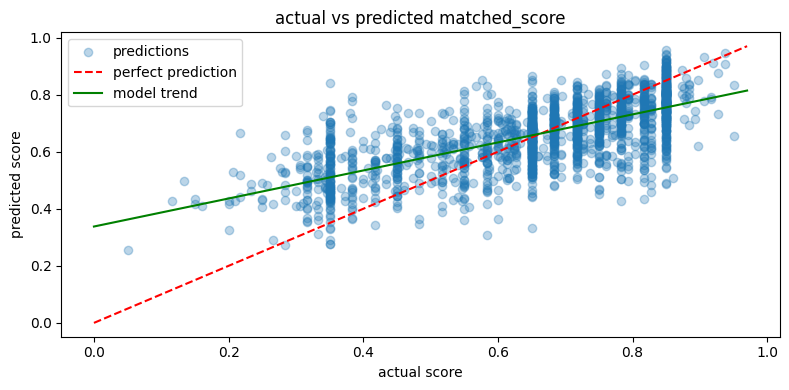

In [152]:
# visualize predictions vs actual

plt.figure(figsize=(8, 4))

# scatter of actual vs predicted values
plt.scatter(y_test, y_pred, alpha=0.3, label='predictions')

# plot perfect prediction line
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='perfect prediction')

# plot a line through the predicted values (our values)
m, b = np.polyfit(y_test, y_pred, 1)
plt.plot([y.min(), y.max()], [m * y.min() + b, m * y.max() + b], 'g-', label='model trend')

plt.legend()

plt.xlabel('actual score')
plt.ylabel('predicted score')
plt.title('actual vs predicted matched_score')
plt.tight_layout()
plt.show()

### what this means / progress

Represents working baseline linear regression model that loosely shows resume-job compatibility scores using tfidf features. It uses four columns of skills, job position name, educational requirements, and responsibilities. We can use it as a simple baseline, but ultimately linear regression can't capture the semantic relationships, and combining candidate and job features into a single input means the model does not actually compare the two sides against each other. Moving towards word embeddings and a neural network will allow us to capture these details and learn a more meaningful representation of resume-job fit.

Despite the limitations, an r2 of 0.47 confirms that there is some signal in the text features. This can also be a concrete benchmark to compare against when we run our word embedding and neural network experiments.

TF-IDF (term frequency-inverse document frequency) scores words based on how frequently they appear relative to the rest of the dataset. The vocabulary and IDF weights are learned from all 9,488 rows, but the TF score is computed individually per row, so each resume-job pair gets its own vector of word weights. In the notebook, we use it to convert the raw text columns into numerical vectors that the regression model can learn from.

For the "resume" portion, we are just using the skills column. 